In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile

# Load CovFit model

In [4]:
MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
FOLD_IDS_TO_USE = [0]
TARGET_FOLD_ID = 0
OUTPUT_PREFIX = "inference_results"
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [5]:
def download_hf_checkpoints(repo_id, fold_ids):
    """
    Download specified fold checkpoint files from Hugging Face
    Hugging Faceから指定されたfoldのckptファイルをダウンロード
    
    Note: The model repository is public, so no token is required.
    注意：モデルリポジトリは公開されているため、トークンは不要です。
    """
    print(f"Downloading checkpoints from {repo_id} for folds: {fold_ids}")
    model_paths = []
    temp_dir = tempfile.mkdtemp()
    
    try:
        for fold_id in fold_ids:
            filename = f"covfit_model_20231102_{fold_id}.ckpt"
            print(f"Downloading {filename}...")
            
            # Download (no token needed for public repository)
            # ダウンロード（公開リポジトリのためトークン不要）
            downloaded_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                cache_dir=temp_dir,
                local_dir="./covfit_stuff/models/"
            )
            model_paths.append(downloaded_path)
            
        print(f"Successfully downloaded {len(model_paths)} checkpoint files")
        return model_paths, temp_dir
        
    except Exception as e:
        # Clean up temporary directory on failure
        # 失敗時はテンポラリディレクトリをクリーンアップ
        shutil.rmtree(temp_dir, ignore_errors=True)
        raise e

In [6]:
model_paths, temp_dir = download_hf_checkpoints(
    repo_id=MODEL_PATH,
    fold_ids=FOLD_IDS_TO_USE
)

task_dict_path = hf_hub_download(
    repo_id=MODEL_PATH,
    filename="task_id_dict.pt"
)

checkpoint = torch.load(model_paths[0], map_location=device)
final_weights = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

original_task_id_infos = torch.load(task_dict_path, map_location=device)
n_targets_original = len(original_task_id_infos)

model_config = ModelConfig()
model_config.da_model_name = model_name

model = load_model_for_inference(model_paths[0], model_config, n_targets_original)
esm_fine_tuned = model.merge_and_unload() #merge PEFT adapter model with the base model and make a fully new model

# dumb thing to make hooked esm and this esm agree
esm_fine_tuned.esm.embeddings.token_dropout = False

# clean up after installing
if temp_dir and os.path.exists(temp_dir):
    shutil.rmtree(temp_dir, ignore_errors=True)
    print("Temporary files cleaned up")

Successfully downloaded 1 checkpoint files
Temporary files cleaned up


In [7]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [8]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name

REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [9]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [11]:
# clean up memory
del model

# Load Data

In [12]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [13]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

# interp data

In [14]:
MAX_LEN=1024
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"

fasta_file = f"../../data/pathogen/{pathogen_name}/alignment.fasta"
data = load_sequences(fasta_file)
sequence_names, sequences = list(zip(*list(data.items())))
uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 


# identical code to how it's compute_node_embeddings.py
protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

tok_output = tokenizer(cut_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(cut_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 1699
torch.Size([1699, 1024])


In [15]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [16]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [17]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [18]:
batch_len = 50
num_data = tok_seqs.size(0)
output_logits = torch.zeros(num_data, d_out_vocab).to(device)
for i in tqdm(range(0,num_data,batch_len)):
    batch_output = get_logit_hooked(hooked_esm(tok_seqs[i:i+batch_len]), list(range(d_out_vocab)))
    output_logits[i:i+batch_len] = batch_output
    torch.cuda.empty_cache()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [03:38<00:00,  6.44s/it]


In [19]:
logit_id = original_task_id_infos["fitness_USA"]
# logit_id = original_task_id_infos["fitness_South Korea"]

In [20]:
topk = 40
high_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=True).indices
low_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=False).indices[list(range(topk-1,-1,-1))]

high_toks = tok_seqs[high_fitness_dset_indices, :]
low_toks = tok_seqs[low_fitness_dset_indices, :]
fitness_dset = torch.cat([low_toks, high_toks], dim=0)

In [22]:
high_logit_mean = get_logit_hooked(hooked_esm(high_toks), logit_id).mean().item()
low_logit_mean = get_logit_hooked(hooked_esm(low_toks), logit_id).mean().item()
print(high_logit_mean - low_logit_mean)
torch.cuda.empty_cache()

0.052038103342056274


# Path patching

<img src="./path_patching_fig.png" width="800"/>

# Path patching cont.

## L31H7, Low fitness into high fitness

In [23]:
def path_patching_metric(
    logits: Float[Tensor, "batch"],
    corrupted_logit_mean: float,
    clean_logit_mean: float,
):
    """
    Equals 0 when performance is conserved (i.e. high fitness sequences still high fitness)
    Equals -1 when performance is destroyed (high fitness sequence is degraded)
    """

    return ((logits - clean_logit_mean) / (clean_logit_mean - corrupted_logit_mean)).mean().item()

In [24]:
def patch_or_freeze_head_vectors(
    orig_head_vector: Float[Tensor, "batch pos head_index d_head"],
    hook: HookPoint,
    new_cache: ActivationCache,
    orig_cache: ActivationCache,
    head_to_patch: tuple[int, int], # [layer, head]
) -> Float[Tensor, "batch pos head_index d_head"]:
    """
    This helps implement step 2 of path patching. We freeze all head outputs (i.e. set them to their
    values in orig_cache), except for head_to_patch (if it's in this layer) which we patch with the
    value from new_cache.

    head_to_patch: tuple of (layer, head)
    """
    # Setting using ..., otherwise changing orig_head_vector will edit cache value too
    orig_head_vector[...] = orig_cache[hook.name][...]
    if head_to_patch[0] == hook.layer():
        orig_head_vector[:, :, head_to_patch[1]] = new_cache[hook.name][:, :, head_to_patch[1]]
    return orig_head_vector

def patch_head_input(
    orig_activation: Float[Tensor, "batch pos head_idx d_head"],
    hook: HookPoint,
    patched_cache: ActivationCache,
    head_list: list[tuple[int, int]],
) -> Float[Tensor, "batch pos head_idx d_head"]:
    """
    Function which can patch any combination of heads in layers,
    according to the heads in head_list.
    """
    heads_to_patch = [head for layer, head in head_list if layer == hook.layer()]
    orig_activation[:, :, heads_to_patch] = patched_cache[hook.name][:, :, heads_to_patch]
    return orig_activation


def get_path_patch_head_to_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str,
    new_dataset: Float[Tensor, "batch pos"],
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache | None,
    orig_cache: ActivationCache | None,
) -> Float[Tensor, "layer head"]:
    """
    Performs path patching (see algorithm in appendix B of IOI paper), with:

        sender head = (each head, looped through, one at a time)
        receiver node = input to a later head (or set of heads)

    The receiver node is specified by receiver_heads and receiver_input, for example if
    receiver_input = "v" and receiver_heads = [(8, 6), (8, 10), (7, 9), (7, 3)], we're doing path
    patching from each head to the value inputs of the S-inhibition heads.

    Returns:
        tensor of metric values for every possible sender head
    """

    num_layers = model.cfg.n_layers
    num_heads = model.cfg.n_heads

    results = torch.zeros((num_layers, num_heads)).to(model.cfg.device)
    z_name_filter = lambda name: name.endswith("z")

    receiver_layers = set([x[0] for x in receiver_heads])
    receiver_hook_names = [utils.get_act_name(receiver_input, layer) for layer in receiver_layers]
    receiver_hook_names_filter = lambda name: name in receiver_hook_names

    # step 1, get cached runs
    if new_cache == None:
        _, new_cache = model.run_with_cache(new_dataset, names_filter=z_name_filter)
        torch.cuda.empty_cache()

    if orig_cache == None:
        _, orig_cache = model.run_with_cache(orig_dataset, names_filter=z_name_filter)
        torch.cuda.empty_cache()

    with tqdm(total = num_layers * num_heads) as fancy_progress_bar:
        for layer in range(num_layers):
            for head in range(num_heads):
                model.reset_hooks()
    
                # step 2, run original dataset with non-direct paths frozen
                step2_hook_f = functools.partial(patch_or_freeze_head_vectors, new_cache=new_cache, orig_cache=orig_cache, head_to_patch=(layer, head))
                model.add_hook(z_name_filter, step2_hook_f, dir="fwd")
                _, patching_cache = model.run_with_cache(orig_dataset, names_filter=receiver_hook_names_filter)
                torch.cuda.empty_cache()
    
                # step 3, compute final logits
                model.reset_hooks()
                step3_hook_f = functools.partial(patch_head_input, patched_cache=patching_cache, head_list=receiver_heads)
                path_patched_logits_esm = model.run_with_hooks(orig_dataset, fwd_hooks=[(receiver_hook_names_filter, step3_hook_f)], return_type="logits")
                path_patched_logits = get_logit_hooked(path_patched_logits_esm, logit_id)
                torch.cuda.empty_cache()
    
                results[layer, head] = patching_metric(path_patched_logits)
                fancy_progress_bar.update()
    model.reset_hooks()
    return results

In [29]:
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

-0.05671152472496033


In [30]:
path_patch_317_qkv = []
for receiver_input in ["k","q","v"]:
    path_patch_317 = get_path_patch_head_to_heads(
        hooked_esm, 
        receiver_heads=[(31,7)], 
        receiver_input=receiver_input, # changing the output "z" of head 31.7 has the strongest direct affect on the logits, so that's what we will be patch-patching into 
        new_dataset=corrupted_toks,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    path_patch_317_qkv.append(path_patch_317)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [53:44<00:00,  4.89s/it]


In [32]:
path_patch_317_tensor = torch.stack(path_patch_317_qkv, dim=0)

#### Fig 22.1 -- direct effect on head 31.7 (from attn.) using path patching

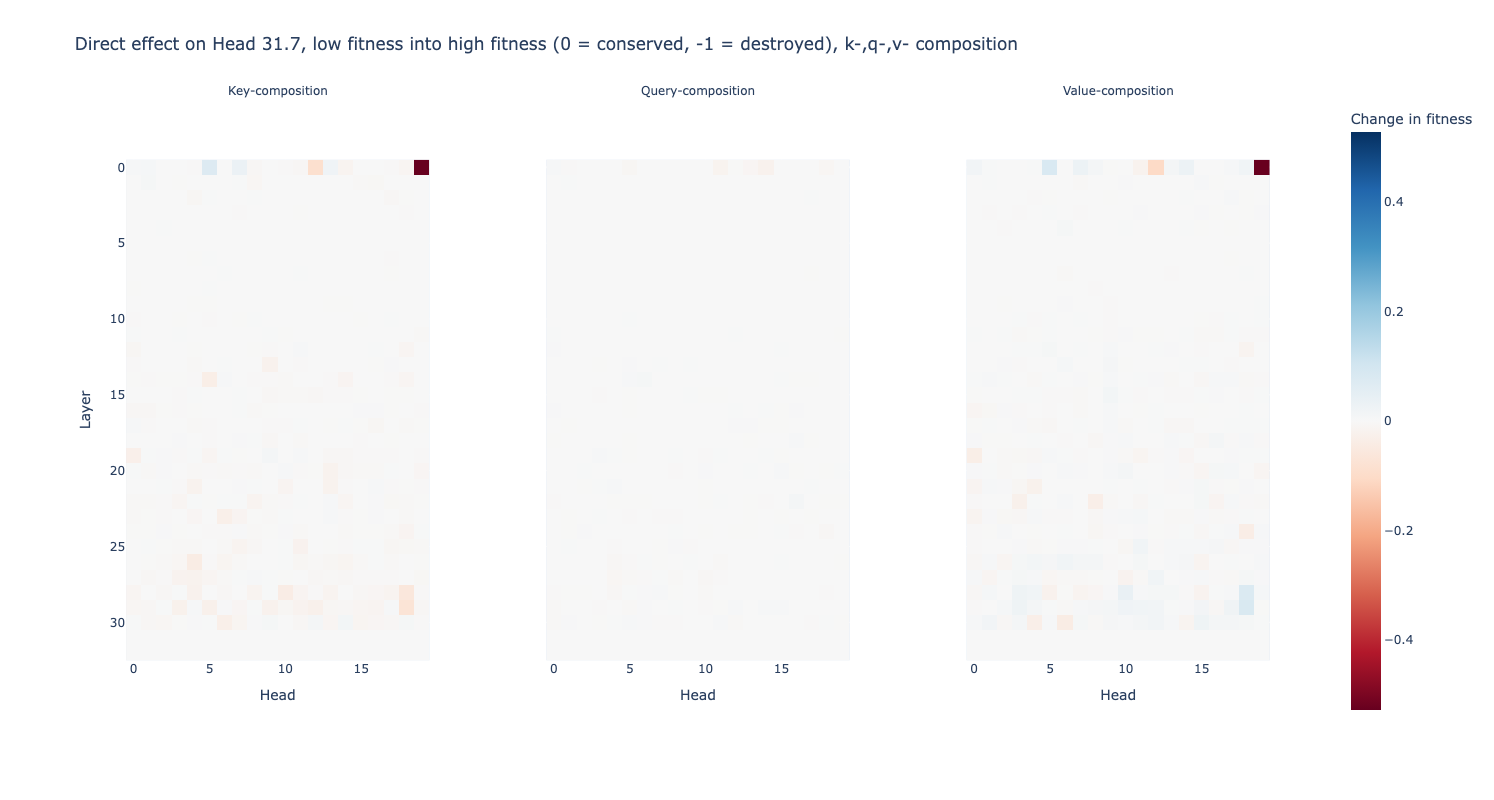

In [33]:
imshow(
    path_patch_317_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Direct effect on Head 31.7, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Key-composition", "Query-composition", "Value-composition"],
    width=1200,
    height=800,
    facet_col=0,
    # range_color=(-1,1)
)

## MLP path-patching to 32.8, LOW into HIGH fitness

In [24]:
def total_freeze_head_vectors(
    orig_head_vector: Float[Tensor, "batch pos head_index d_head"],
    hook: HookPoint,
    orig_cache: ActivationCache,
) -> Float[Tensor, "batch pos head_index d_head"]:
    """
    This helps implement step 2 of path patching. We freeze all head outputs (i.e. set them to their
    values in orig_cache), except for head_to_patch (if it's in this layer) which we patch with the
    value from new_cache.

    head_to_patch: tuple of (layer, head)
    """
    # Setting using ..., otherwise changing orig_head_vector will edit cache value too
    orig_head_vector[...] = orig_cache[hook.name][...]
    return orig_head_vector

def path_patch_mlp_vector(
    orig_mlp_vector: Float[Tensor, "batch pos d_mlp"],
    hook: HookPoint,
    new_cache: ActivationCache
) -> Float[Tensor, "batch pos d_mlp"]:
    """
    Patches the output of a given mlp (before it's added to the residual stream) at every sequence
    position, using the value from the corrupted cache.
    """
    orig_mlp_vector[...] = new_cache[hook.name][...]
    return orig_mlp_vector


def get_path_patch_mlp_to_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str,
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache,
    orig_cache: ActivationCache,
) -> Float[Tensor, "layer head"]:
    """
    Performs path patching (see algorithm in appendix B of IOI paper), with:

        sender head = (each head, looped through, one at a time)
        receiver node = input to a later head (or set of heads)

    The receiver node is specified by receiver_heads and receiver_input, for example if
    receiver_input = "v" and receiver_heads = [(8, 6), (8, 10), (7, 9), (7, 3)], we're doing path
    patching from each head to the value inputs of the S-inhibition heads.

    Returns:
        tensor of metric values for every possible sender head
    """

    num_layers = model.cfg.n_layers
    num_heads = model.cfg.n_heads

    results = torch.zeros((num_layers)).to(model.cfg.device)
    z_name_filter = lambda name: name.endswith("z")

    receiver_layers = set([x[0] for x in receiver_heads])
    receiver_hook_names = [utils.get_act_name(receiver_input, layer) for layer in receiver_layers]
    receiver_hook_names_filter = lambda name: name in receiver_hook_names
    
    with tqdm(total = num_layers * 1) as fancy_progress_bar:
        for layer in range(num_layers):
            mlp_name = f"blocks.{layer}.hook_mlp_out"
            model.reset_hooks()

            # step 2, run original dataset with non-direct paths frozen
            # freeze all attn. heads
            step21_hook_f = functools.partial(total_freeze_head_vectors, orig_cache=orig_cache)
            model.add_hook(z_name_filter, step21_hook_f, dir="fwd")
            # patch in mlp head
            step22_hook_f = functools.partial(path_patch_mlp_vector, new_cache=new_cache)
            model.add_hook(lambda comp_name: comp_name == mlp_name, step22_hook_f, dir="fwd")
            _, patching_cache = model.run_with_cache(orig_dataset, names_filter=receiver_hook_names_filter)
            torch.cuda.empty_cache()

            # step 3, compute final logits
            model.reset_hooks()
            step3_hook_f = functools.partial(patch_head_input, patched_cache=patching_cache, head_list=receiver_heads)
            path_patched_logits_esm = model.run_with_hooks(orig_dataset, fwd_hooks=[(receiver_hook_names_filter, step3_hook_f)], return_type="logits")
            path_patched_logits = get_logit_hooked(path_patched_logits_esm, logit_id)
            torch.cuda.empty_cache()

            results[layer] = patching_metric(path_patched_logits)
            fancy_progress_bar.update()
    model.reset_hooks()
    return results

In [104]:
all_mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

# cache attention outputs
# only need attn. z in orig_cache
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
# only need mlp in new_cache
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()

-0.05671152472496033


In [105]:
path_patch_mlp_328_all = []
for receiver_input in ["k","q","v"]:
    path_patch_mlp_328 = get_path_patch_mlp_to_heads(
        hooked_esm,
        receiver_heads=[(32,8)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache,
    )
    path_patch_mlp_328_all.append(path_patch_mlp_328)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [02:41<00:00,  4.89s/it]


In [106]:
path_patch_mlp_328_tensor = torch.stack(path_patch_mlp_328_all, dim=0)

#### Fig 22.2 -- direct effect on head 32.8 (from MLP) using path patching

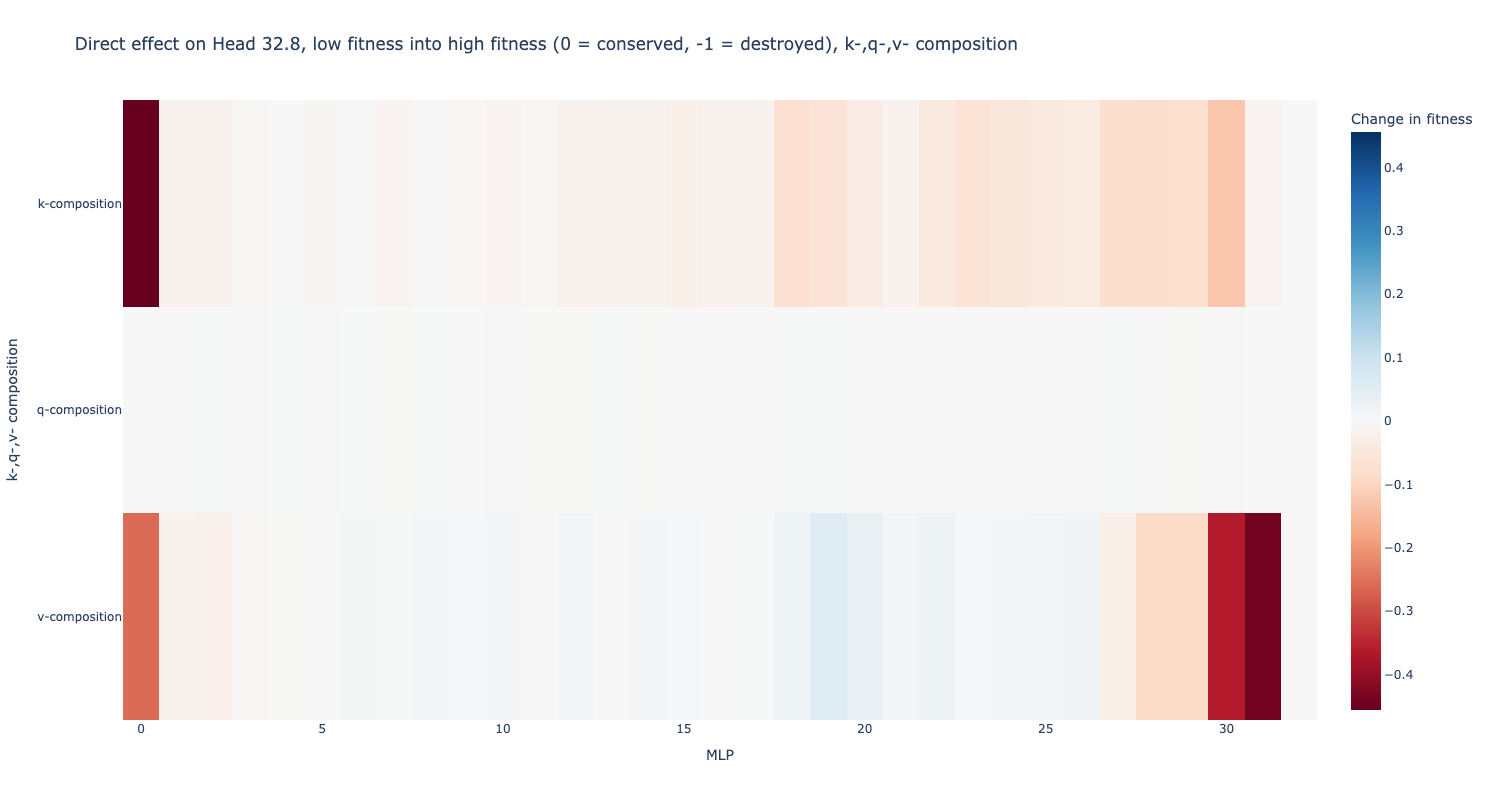

In [107]:
imshow(
    path_patch_mlp_328_tensor,
    labels={"x": "MLP", "y": "k-,q-,v- composition", "color": "Change in fitness"},
    title="Direct effect on Head 32.8, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    width=1200,
    height=800,
    y = ["k-composition","q-composition","v-composition"]        
    # range_color=(-1,1)
)

## MLP path-patching to 31.7, LOW into HIGH fitness

In [108]:
path_patch_mlp_317_all = []
for receiver_input in ["k","q","v"]:
    path_patch_mlp_317 = get_path_patch_mlp_to_heads(
        hooked_esm,
        receiver_heads=[(31,7)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache,
    )
    path_patch_mlp_317_all.append(path_patch_mlp_317)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [02:41<00:00,  4.89s/it]


In [111]:
path_patch_mlp_317_tensor = torch.stack(path_patch_mlp_317_all, dim=0)

#### Fig 22.3 -- direct effect on head 31.7 (from MLP) using path patching

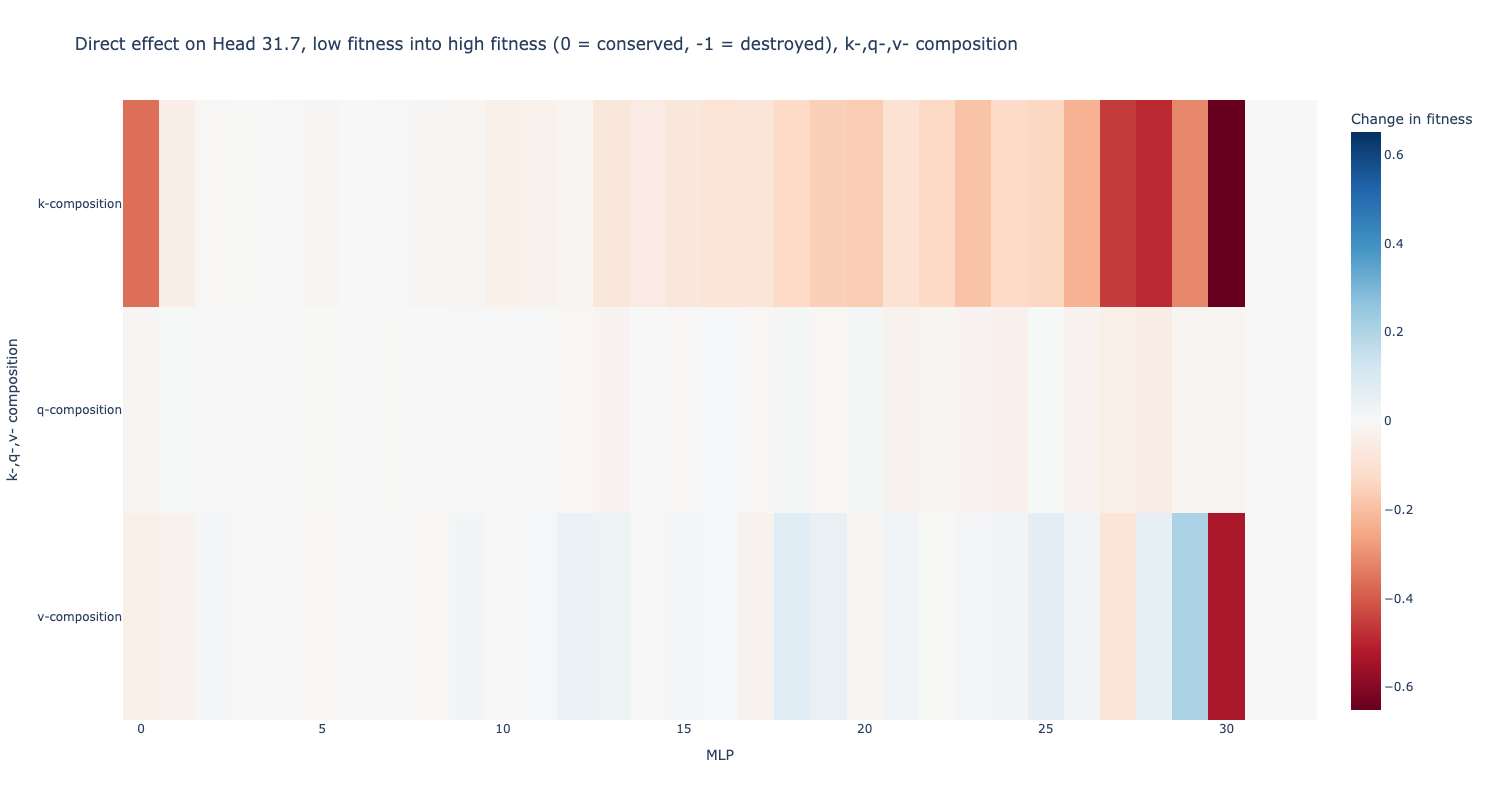

In [112]:
imshow(
    path_patch_mlp_317_tensor,
    labels={"x": "MLP", "y": "k-,q-,v- composition", "color": "Change in fitness"},
    title="Direct effect on Head 31.7, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    width=1200,
    height=800,
    y = ["k-composition","q-composition","v-composition"]        
    # range_color=(-1,1)
)

# Absolute Path patching, LOW into HIGH fitness

## That is, I'm freezing everything except residual stream

<img src="./absolute_patching_fig.png" width="1200"/>

In [25]:
def path_patch_head_absolute_direct(
    model,
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache,
    logit_id,
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_path_results = torch.zeros(num_layers, num_heads)

    z_name_list = [f"blocks.{layer}.attn.hook_z" for layer in range(num_layers)]
    names_filter = ["blocks.32.hook_resid_post", *z_name_list]
    _, orig_cache = hooked_esm.run_with_cache(orig_dataset, names_filter=names_filter)

    esm_output = orig_cache["blocks.32.hook_resid_post"] # [batch pos d_model]
    final_ln = hooked_esm.ln_final
    
    torch.cuda.empty_cache()
    
    with tqdm(total = num_layers * num_heads) as fancy_progress_bar:
        for layer in range(num_layers):
            W_O_layer = hooked_esm.W_O[layer] # [n_head d_head d_model]
            b_O_layer = hooked_esm.b_O[layer]
 
            for head in range(num_heads):
                head_name = f"blocks.{layer}.attn.hook_z"
                layer_head_output_orig = einops.einsum(orig_cache[head_name], W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                layer_head_z_new = orig_cache[head_name].detach().clone() # [batch pos n_head d_head]
                layer_head_z_new[:,:,head,:] = new_cache[head_name][:,:,head,:]
                layer_head_output_new = einops.einsum(layer_head_z_new, W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                path_patched_logit = final_ln(esm_output - layer_head_output_orig + layer_head_output_new)
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(path_patched_logit, logit_id)
                torch.cuda.empty_cache()
        
                path_path_results[layer, head] = patching_metric(path_patched_logits)
                
                fancy_progress_bar.update()

    return path_path_results

In [99]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [100]:
# only need attention info
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [104]:
abs_patch_head = path_patch_head_absolute_direct(
    hooked_esm, 
    orig_dataset=clean_toks, 
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    new_cache=new_cache,
    logit_id=logit_id
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [00:06<00:00, 107.14it/s]


#### Fig 22.4 -- Absolute path patching (HIGH into LOW) from attn. to final logit

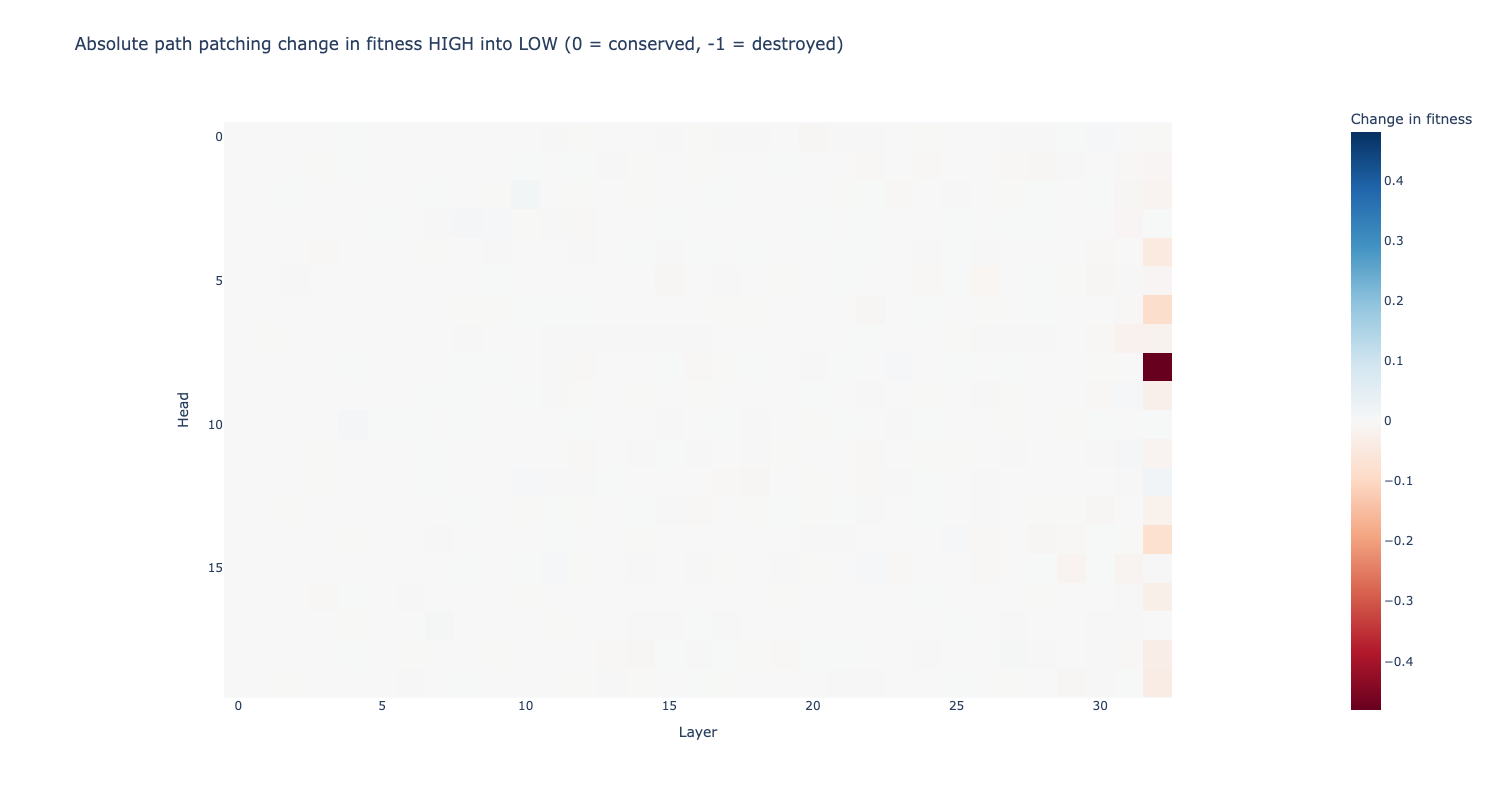

In [105]:
imshow(
    abs_patch_head.T,
    labels={"x": "Layer", "y": "Head", "color": "Change in fitness"},
    title="Absolute path patching change in fitness HIGH into LOW (0 = conserved, -1 = destroyed)",
    width=1200,
    height=800
)

In [26]:
def path_patch_mlp_absolute_direct(
    model,
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache,
    logit_id=logit_id,
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    path_patch_results = torch.zeros(num_layers).to(device)

    mlp_names_filter = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]
    names_filter = ["blocks.32.hook_resid_post", *mlp_names_filter]
    _, orig_cache = hooked_esm.run_with_cache(orig_dataset, names_filter=names_filter)

    esm_output = orig_cache["blocks.32.hook_resid_post"] # [batch pos d_model]
    final_ln = hooked_esm.ln_final
    
    torch.cuda.empty_cache()
    
    with tqdm(total = num_layers * 1) as fancy_progress_bar:
        for layer in range(num_layers):
            mlp_name = mlp_names_filter[layer] 
            mlp_orig_output = orig_cache[mlp_name] # [batch pos d_model]
            mlp_new_output = new_cache[mlp_name] # [batch pos d_model]

            path_patched_logit = final_ln(esm_output - mlp_orig_output + mlp_new_output) # [batch pos d_model]
            # step 3, compute final logits
            path_patched_logits = get_logit_hooked(path_patched_logit, tok_id=logit_id) # [batch]
            path_patch_results[layer] = patching_metric(path_patched_logits)
            torch.cuda.empty_cache()
            fancy_progress_bar.update()

    return path_patch_results

In [114]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [115]:
all_mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]
# only need mlp info
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()

In [119]:
absolute_path_patch_mlp_results = path_patch_mlp_absolute_direct(
    hooked_esm,
    orig_dataset=clean_toks,
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    new_cache=new_cache
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:00<00:00, 666.84it/s]


#### Fig 22.5 -- Absolute path patching (HIGH into LOW) from MLP to final logit

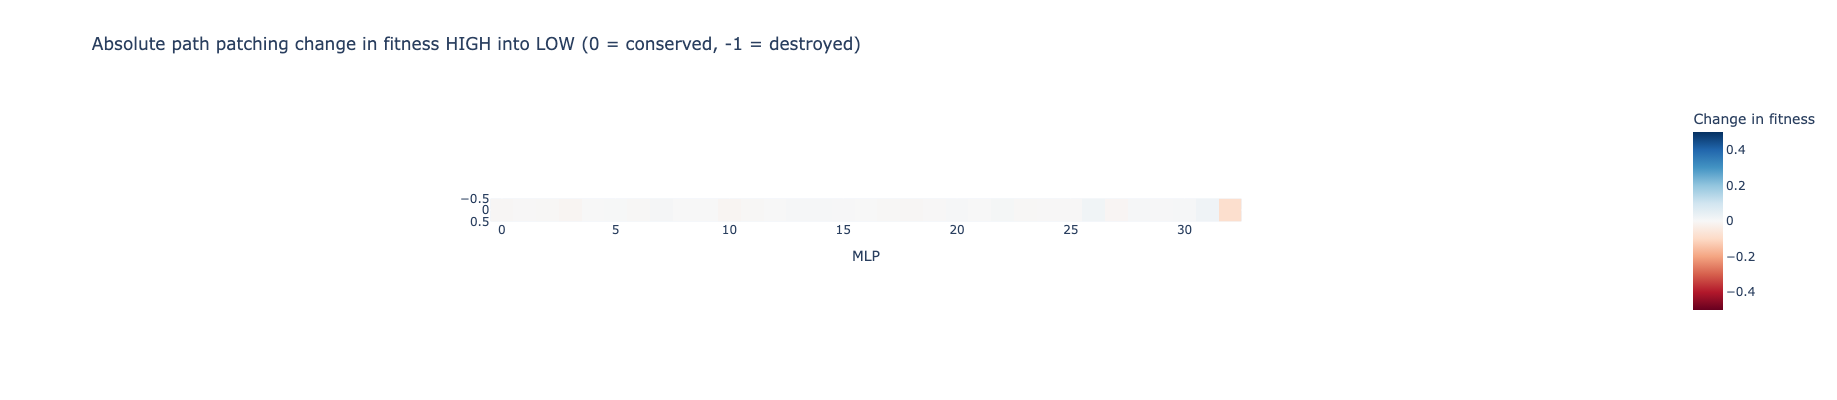

In [120]:
imshow(
    absolute_path_patch_mlp_results[None,:],
    labels={"x": "MLP", "y": "", "color": "Change in fitness"},
    title="Absolute path patching change in fitness HIGH into LOW (0 = conserved, -1 = destroyed)",
    width=1000,
    height=400,
    range_color=(-0.5,0.5)
)

## Absolute path patching into 32.8, 31.7

### Asbolute path patching 32.8 - (1) Attn. heads and (2) MLP

### Fix $x\in \{q,k,v\}$
### Observe that:
### $resid^{(layer)} = \sum_{\ell=1}^{layer} \left(\left(\sum_{j=1}^{num\_heads}\text{Attn\_out}^{\ell}_{j}\right) + \text{MLP\_out}^{\ell}\right)$. Thus, $\, \text{x\_vector}^{layer} = W_x \,@\,LN^{layer}(resid^{layer})$.
### To measure absolute effect of component, I simply take my component and perform the procedure as detailed in Abs. path patching png above

# absolute patch patching attn. to receiver heads

In [25]:
def abs_path_patch_head_input(
    orig_head_vector: Float[Tensor, "batch pos n_head d_head"],
    hook: HookPoint,
    new_comp: Float[Tensor, "batch pos d_head"], # changed_head_vector at head_idx
    head_idx: int
):
    orig_head_vector[:,:,head_idx,:] = new_comp
    return orig_head_vector
    

def abs_path_patch_receiver_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str, #one of {"q", "k", "v"}
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached attn. z
    orig_cache: ActivationCache, # cached attn. z
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers, num_heads)

    # inputs to receiver head are output of prev layer
    receiver_layer_inputs = [x[0] - 1 for x in receiver_heads]

    # receiver head layers
    receiver_layers = [x[0] for x in receiver_heads]
    
    layer_head_lns = [model.blocks[layer].ln1 for layer in receiver_layers]
    resid_post_names = [f"blocks.{layer}.hook_resid_post" for layer in receiver_layer_inputs]
    _, resid_post_cache = model.run_with_cache(high_toks, names_filter = resid_post_names)
    torch.cuda.empty_cache()

    W_receiver = {"q": model.W_Q, "k": model.W_K, "v": model.W_V}[receiver_input]
    b_receiver = {"q": model.b_Q, "k": model.b_K, "v": model.b_V}[receiver_input]
    
    with tqdm(total = max(receiver_layers) * num_heads) as fancy_progress_bar:
        for layer in range(max(receiver_layers)):
            W_O_layer = hooked_esm.W_O[layer] # [n_head d_head d_model]
            b_O_layer = hooked_esm.b_O[layer]
 
            for head in range(num_heads):
                model.reset_hooks()
                head_name = f"blocks.{layer}.attn.hook_z"

                # STEP 2
                # new_resid_input= old_resid_input - old_head_output + new_head_output
                # new_head_output
                new_head_z = orig_cache[head_name].detach().clone() # [batch pos n_head d_head]
                new_head_z[:,:, head, :] = new_cache[head_name][:,:,head,:] # [batch pos n_head d_head]
                new_head_output = einops.einsum(new_head_z, W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]
                # old_head_output
                orig_head_output = einops.einsum(orig_cache[head_name], W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
                for r_ln, r_post_name, (rl, rh) in zip(layer_head_lns, resid_post_names, receiver_heads):
                    new_resid_input = r_ln(resid_post_cache[r_post_name] - orig_head_output + new_head_output)
                    new_comp = einops.einsum(new_resid_input, W_receiver[rl], "batch pos d_model, n_head d_model d_head -> batch pos n_head d_head") + b_receiver[rl] # [batch pos n_head d_head]
                    
                    model.add_hook(
                        utils.get_act_name(receiver_input, rl), 
                        functools.partial(abs_path_patch_head_input, new_comp=new_comp[:,:,rh,:], head_idx=rh), 
                        dir="fwd"
                    )
                
                path_patched_logits = model(orig_dataset) # [batch pos d_model]
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
                torch.cuda.empty_cache()
        
                path_patch_results[layer, head] = patching_metric(path_patched_logits)
                
                fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results

In [63]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [64]:
# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [53]:
abs_path_patch_all_328 = []
for receiver_input in ["k","q","v"]:
    abs_path_patch_comp_328 = abs_path_patch_receiver_heads(
        hooked_esm, 
        receiver_heads = [(32,8)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    abs_path_patch_all_328.append(abs_path_patch_comp_328)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 640/640 [44:45<00:00,  4.20s/it]


In [54]:
abs_path_patch_328_tensor = torch.stack(abs_path_patch_all_328, dim=0)

#### Fig 22.5 -- Absolute path patching (HIGH into LOW) from attn. to 32.8

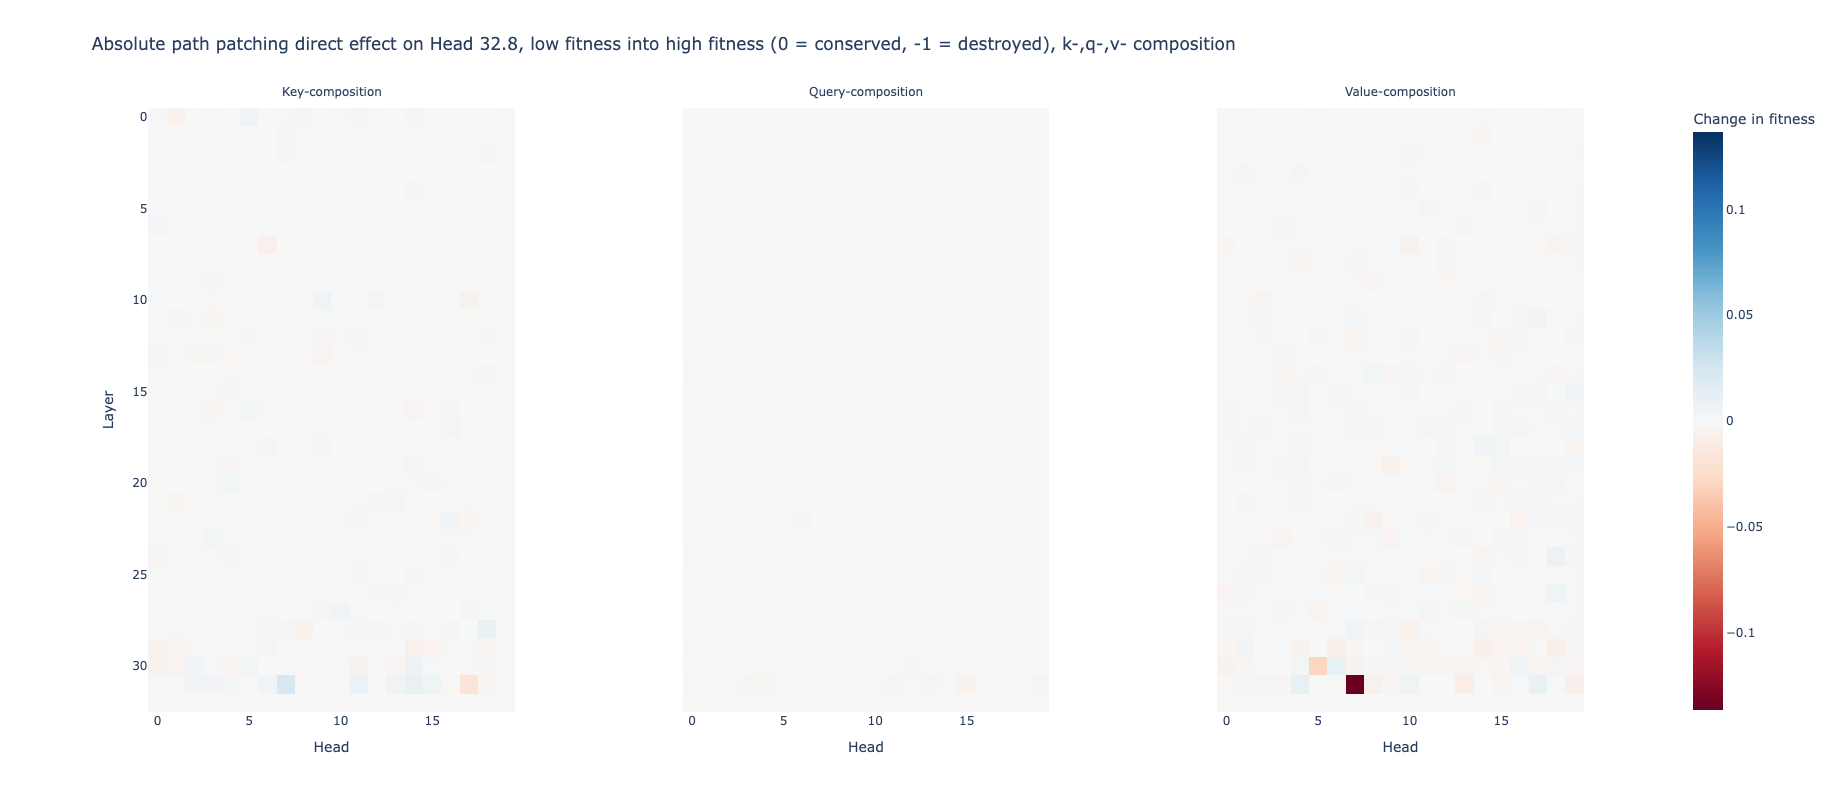

In [75]:
imshow(
    abs_path_patch_328_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 32.8, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Key-composition", "Query-composition", "Value-composition"],
    width=1400,
    height=800,
    facet_col=0,
    # range_color=(-0.5,0.5)
)

In [65]:
abs_path_patch_all_317 = []
for receiver_input in ["k","q","v"]:
    abs_path_patch_comp_317 = abs_path_patch_receiver_heads(
        hooked_esm, 
        receiver_heads = [(31,7)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    abs_path_patch_all_317.append(abs_path_patch_comp_317)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 620/620 [25:26<00:00,  2.46s/it]


In [66]:
abs_path_patch_317_tensor = torch.stack(abs_path_patch_all_317, dim=0)

#### Fig 22.6 -- Absolute path patching (HIGH into LOW) from attn. to 31.7

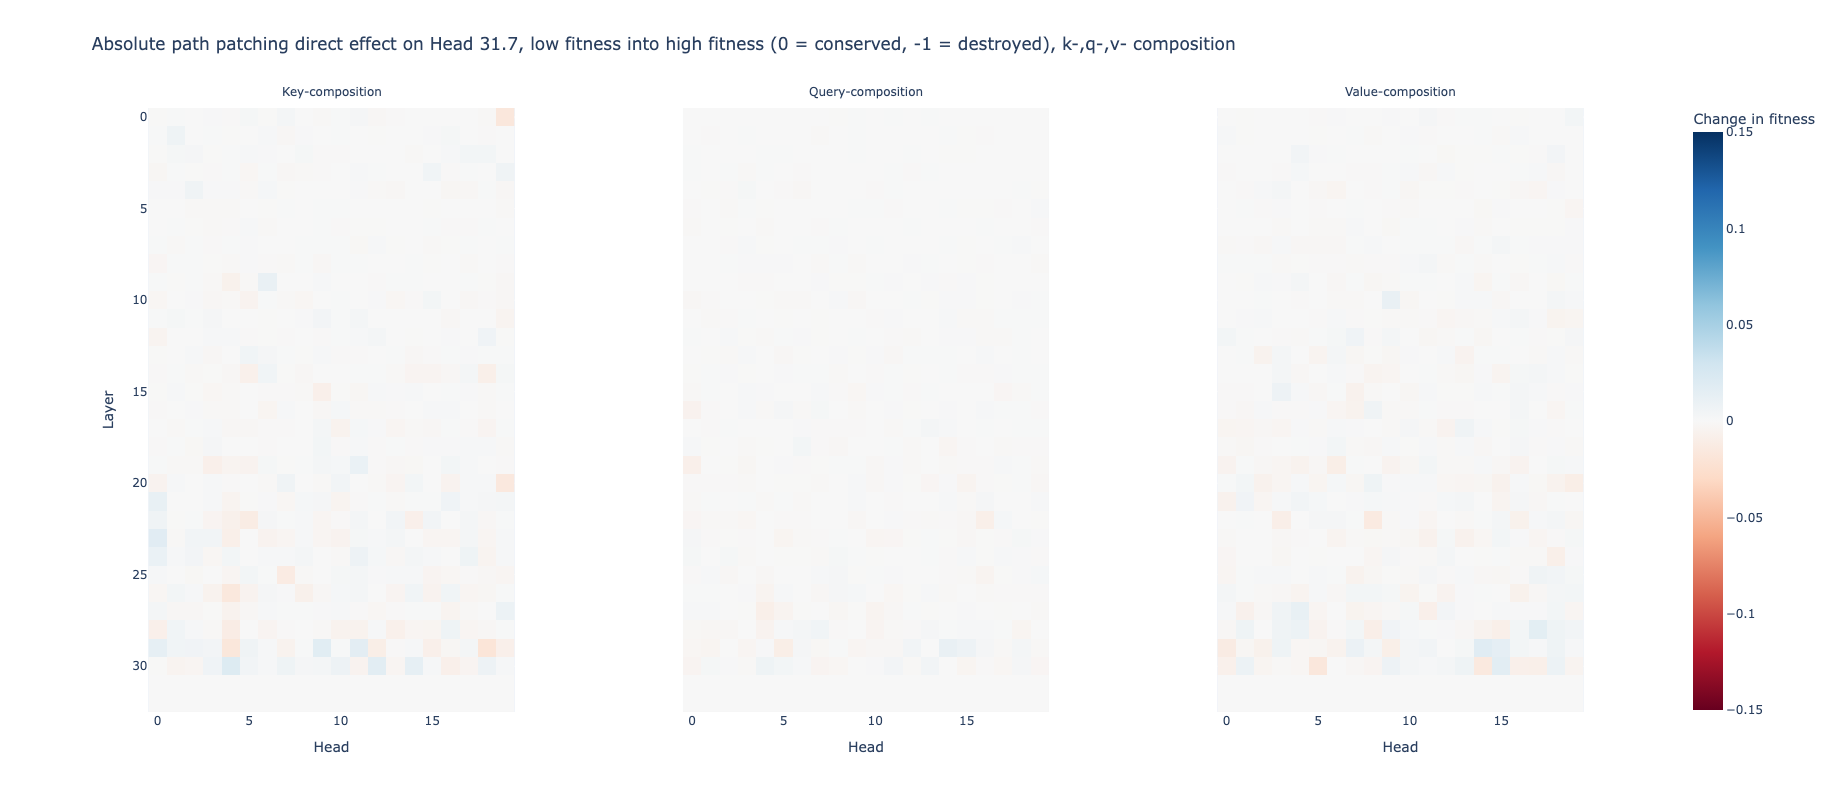

In [122]:
imshow(
    abs_path_patch_317_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 31.7, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Key-composition", "Query-composition", "Value-composition"],
    width=1400,
    height=800,
    facet_col=0,
    range_color=(-0.15,0.15)
)

In [26]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [27]:
# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [28]:
abs_path_patch_all_2918 = []
for receiver_input in ["k","q","v"]:
    abs_path_patch_comp_2918 = abs_path_patch_receiver_heads(
        hooked_esm, 
        receiver_heads = [(29,18)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    abs_path_patch_all_2918.append(abs_path_patch_comp_2918)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 580/580 [23:48<00:00,  2.46s/it]


In [29]:
abs_path_patch_2918_tensor = torch.stack(abs_path_patch_all_2918, dim=0)

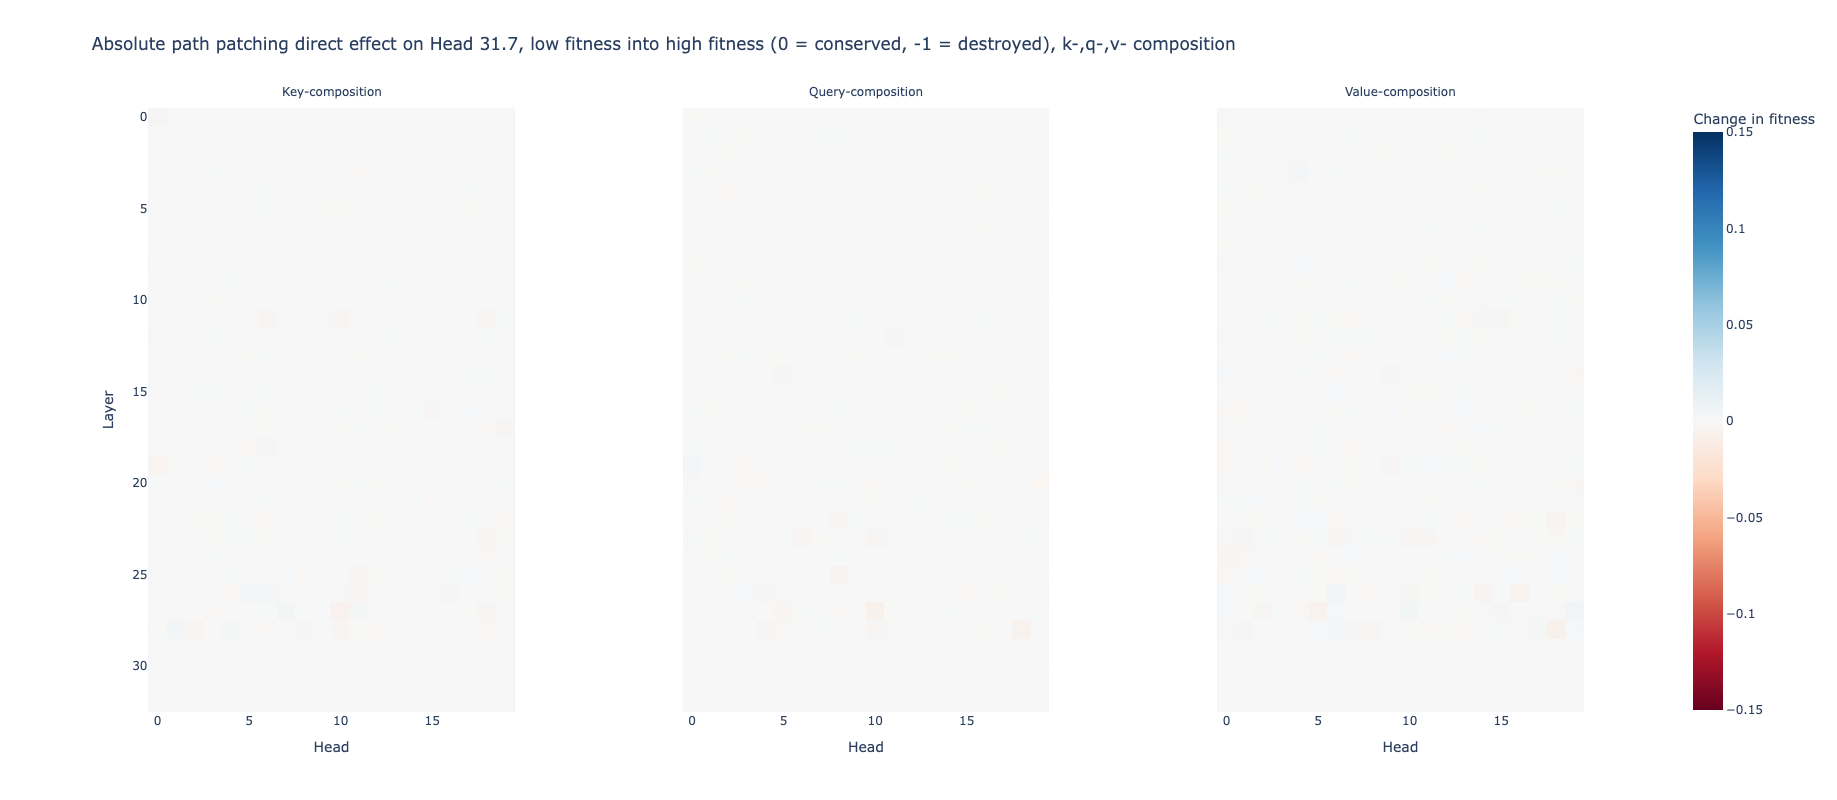

In [32]:
imshow(
    abs_path_patch_2918_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 31.7, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Key-composition", "Query-composition", "Value-composition"],
    width=1400,
    height=800,
    facet_col=0,
    range_color=(-0.15,0.15)
)

# absolute patch patching MLP to receiver heads

In [28]:
def abs_path_patch_mlp_to_receiver_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str, #one of {"q", "k", "v"}
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached mlp
    orig_cache: ActivationCache, # cached mlp
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers)

    # inputs to receiver head are output of prev layer
    receiver_layer_inputs = [x[0] - 1 for x in receiver_heads]

    # receiver head layers
    receiver_layers = [x[0] for x in receiver_heads]
    
    layer_head_lns = [model.blocks[layer].ln1 for layer in receiver_layers]
    resid_post_names = [f"blocks.{layer}.hook_resid_post" for layer in receiver_layer_inputs]
    _, resid_post_cache = model.run_with_cache(high_toks, names_filter = resid_post_names)
    torch.cuda.empty_cache()

    W_receiver = {"q": model.W_Q, "k": model.W_K, "v": model.W_V}[receiver_input]
    b_receiver = {"q": model.b_Q, "k": model.b_K, "v": model.b_V}[receiver_input]
    
    with tqdm(total = max(receiver_layers)) as fancy_progress_bar:
        for layer in range(max(receiver_layers)):
            model.reset_hooks()
            mlp_layer_name = f"blocks.{layer}.hook_mlp_out"

            # STEP 2
            # new_resid_input= old_resid_input - old_head_output + new_head_output
            # new_head_output
            new_mlp_output = new_cache[mlp_layer_name]
            # old_head_output
            orig_mlp_output = orig_cache[mlp_layer_name]

            # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
            for r_ln, r_post_name, (rl, rh) in zip(layer_head_lns, resid_post_names, receiver_heads):
                new_resid_input = r_ln(resid_post_cache[r_post_name] - orig_mlp_output + new_mlp_output)
                new_comp = einops.einsum(new_resid_input, W_receiver[rl], "batch pos d_model, n_head d_model d_head -> batch pos n_head d_head") + b_receiver[rl] # [batch pos n_head d_head]
                
                model.add_hook(
                    utils.get_act_name(receiver_input, rl), 
                    functools.partial(abs_path_patch_head_input, new_comp=new_comp[:,:,rh,:], head_idx=rh), 
                    dir="fwd"
                )
            
            path_patched_logits = model(orig_dataset) # [batch pos d_model]
            # step 3, compute final logits
            path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
            torch.cuda.empty_cache()
    
            path_patch_results[layer] = patching_metric(path_patched_logits)
            
            fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results

In [78]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [79]:
mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

In [81]:
# cache MLP outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=mlp_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=mlp_names)
torch.cuda.empty_cache()

In [83]:
abs_path_patch_mlp_all_328 = []
for receiver_input in ["k","q","v"]:
    abs_path_patch_comp_328 = abs_path_patch_mlp_to_receiver_heads(
        hooked_esm, 
        receiver_heads = [(32,8)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    abs_path_patch_mlp_all_328.append(abs_path_patch_comp_328)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [01:18<00:00,  2.45s/it]


In [88]:
abs_path_patch_mlp_all_328_tensor = torch.stack(abs_path_patch_mlp_all_328, dim=0)
hooked_esm.reset_hooks(including_permanent=False)

#### Fig 22.6 -- Absolute path patching (HIGH into LOW) from MLP to 32.8

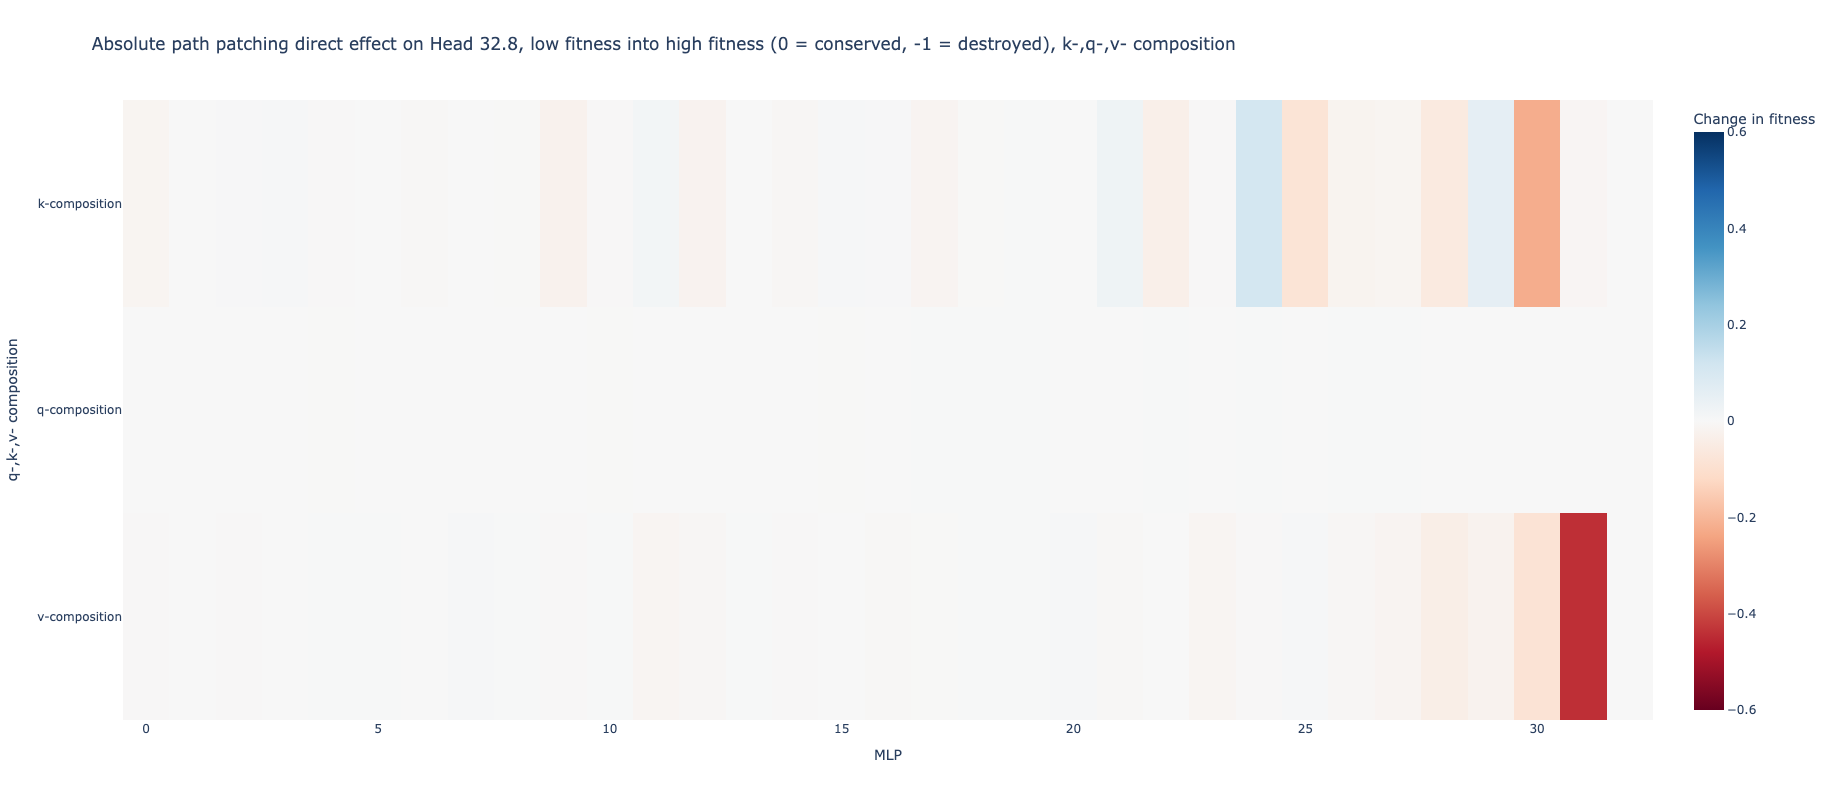

In [99]:
imshow(
    abs_path_patch_mlp_all_328_tensor,
    labels={"x": "MLP", "y": "q-,k-,v- composition", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 32.8, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    width=1300,
    height=800,
    y = ["k-composition","q-composition","v-composition"], 
    range_color=(-0.6,0.6)
)

In [90]:
abs_path_patch_mlp_all_317 = []
for receiver_input in ["k","q","v"]:
    abs_path_patch_comp_317 = abs_path_patch_mlp_to_receiver_heads(
        hooked_esm, 
        receiver_heads = [(31,7)],
        receiver_input=receiver_input,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    abs_path_patch_mlp_all_317.append(abs_path_patch_comp_317)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [01:15<00:00,  2.45s/it]


In [92]:
abs_path_patch_mlp_all_317_tensor = torch.stack(abs_path_patch_mlp_all_317, dim=0)
hooked_esm.reset_hooks(including_permanent=False)

#### Fig 22.7 -- Absolute path patching (HIGH into LOW) from MLP to 31.7

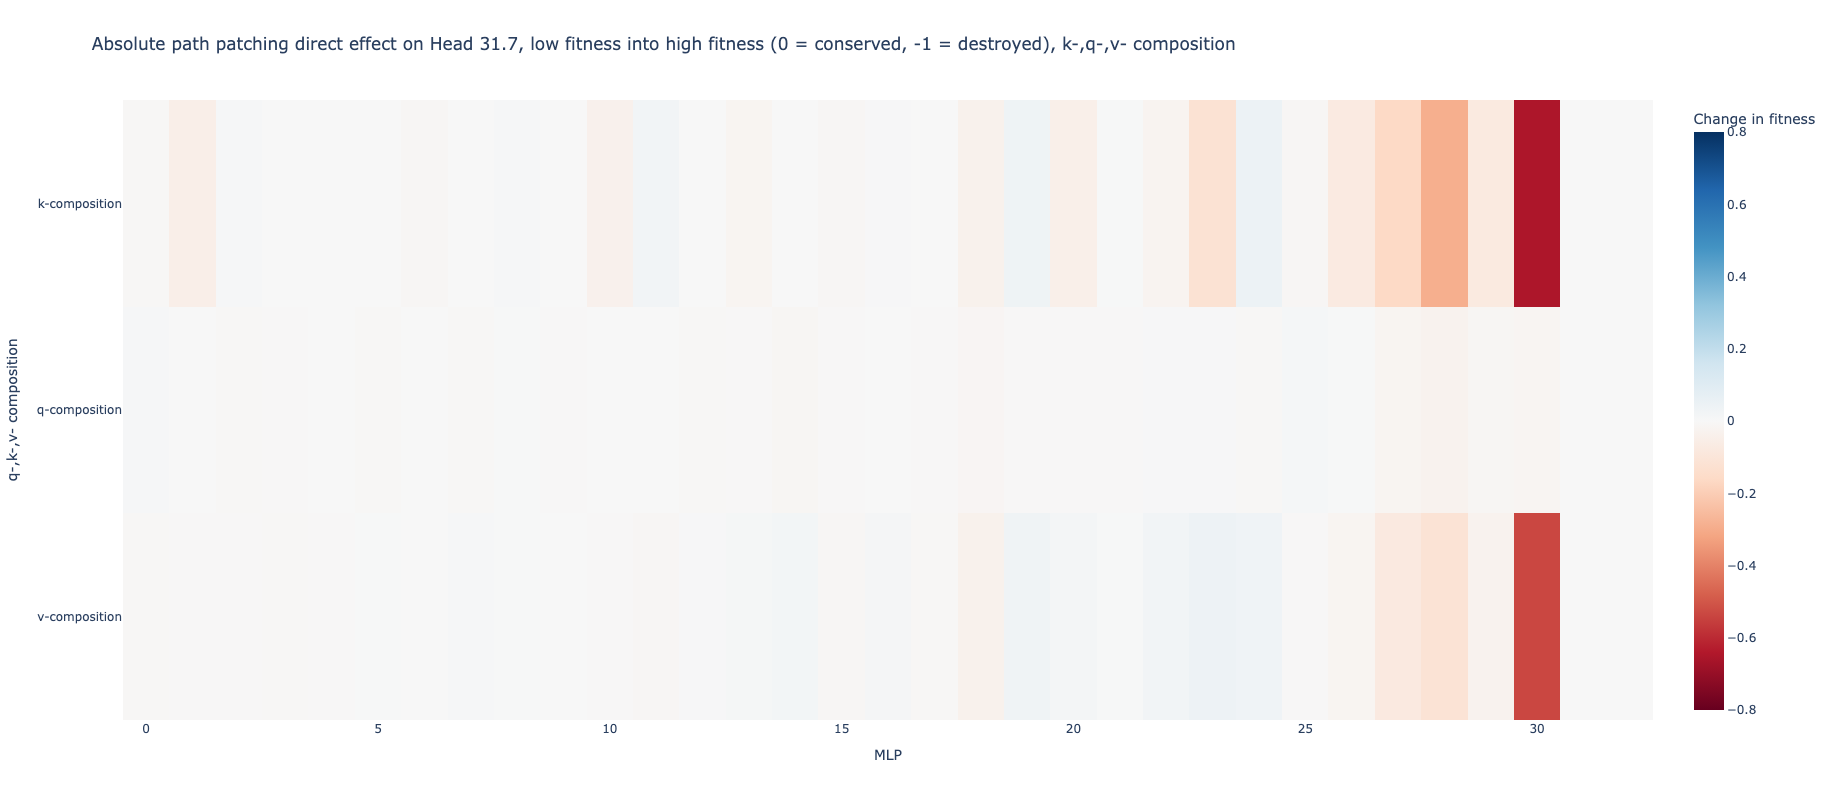

In [124]:
imshow(
    abs_path_patch_mlp_all_317_tensor,
    labels={"x": "MLP", "y": "q-,k-,v- composition", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 31.7, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    width=1300,
    height=800,
    y = ["k-composition","q-composition","v-composition"],
    range_color=(-0.8,0.8)
)

## Absolute path patching into MLP 32, MLP 31, MLP 30, MLP 28

In [28]:
def abs_path_patch_mlp_input(
    orig_mlp_vector: Float[Tensor, "batch pos d_mlp"],
    hook: HookPoint,
    new_comp: Float[Tensor, "batch pos d_mlp"], # changed_mlp_vector
):
    orig_mlp_vector[...] = new_comp[...]
    return orig_mlp_vector


def abs_path_patch_to_mlp(
    model: HookedTransformer,
    receiver_mlps: list[int], # (layers)
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached attn. z
    orig_cache: ActivationCache, # cached attn. z
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers, num_heads)
    
    layer_head_lns = [model.blocks[layer].ln2 for layer in receiver_mlps]
    resid_mid_names = [f"blocks.{layer}.hook_resid_mid" for layer in receiver_mlps]
    _, resid_mid_cache = model.run_with_cache(high_toks, names_filter = resid_mid_names)
    torch.cuda.empty_cache()

    W_mlp_in = model.W_in # [n_layer d_model d_mlp]
    b_mlp_in = model.b_in # # [n_layer d_mlp]
    
    with tqdm(total = (max(receiver_mlps) + 1) * num_heads) as fancy_progress_bar:
        for layer in range(max(receiver_mlps) + 1):
            W_O_layer = hooked_esm.W_O[layer] # [n_head d_head d_model]
            b_O_layer = hooked_esm.b_O[layer]
 
            for head in range(num_heads):
                model.reset_hooks()
                head_name = f"blocks.{layer}.attn.hook_z"

                # STEP 2
                # new_resid_input= old_resid_input - old_head_output + new_head_output
                # new_head_output
                new_head_z = orig_cache[head_name].detach().clone() # [batch pos n_head d_head]
                new_head_z[:,:, head, :] = new_cache[head_name][:,:,head,:] # [batch pos n_head d_head]
                new_head_output = einops.einsum(new_head_z, W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]
                # old_head_output
                orig_head_output = einops.einsum(orig_cache[head_name], W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
                for r_ln, r_post_name, rl in zip(layer_head_lns, resid_mid_names, receiver_mlps):
                    # only patch in things from earlier layers (including current layer since MHA comes before MLP)
                    if rl >= layer:
                        receiver_mlp_name = f"blocks.{rl}.mlp.hook_pre"
                        new_resid_input = r_ln(resid_mid_cache[r_post_name] - orig_head_output + new_head_output)
                        new_comp = einops.einsum(new_resid_input, W_mlp_in[rl], "batch pos d_model, d_model d_mlp -> batch pos d_mlp") + b_mlp_in[rl] # [batch pos n_head d_head]
                        
                        model.add_hook(
                            receiver_mlp_name, 
                            functools.partial(abs_path_patch_mlp_input, new_comp=new_comp), 
                            dir="fwd"
                        )
                
                path_patched_logits = model(orig_dataset) # [batch pos d_model]
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
                torch.cuda.empty_cache()
        
                path_patch_results[layer, head] = patching_metric(path_patched_logits)
                
                fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results

In [38]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [39]:
# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [40]:
head_path_patch_all_mlp = []
for mlp_idx in [32, 31, 30, 29, 28, 27, 24]:
    head_path_patch_mlp_i = abs_path_patch_to_mlp(
        hooked_esm,
        receiver_mlps = [mlp_idx],
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    head_path_patch_all_mlp.append(head_path_patch_mlp_i)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [20:41<00:00,  2.48s/it]


In [41]:
head_path_patch_all_mlp_tensor = torch.stack(head_path_patch_all_mlp, dim=0)

#### Fig 22.8 -- Absolute path patching (HIGH into LOW) from attn. to diff MLPs

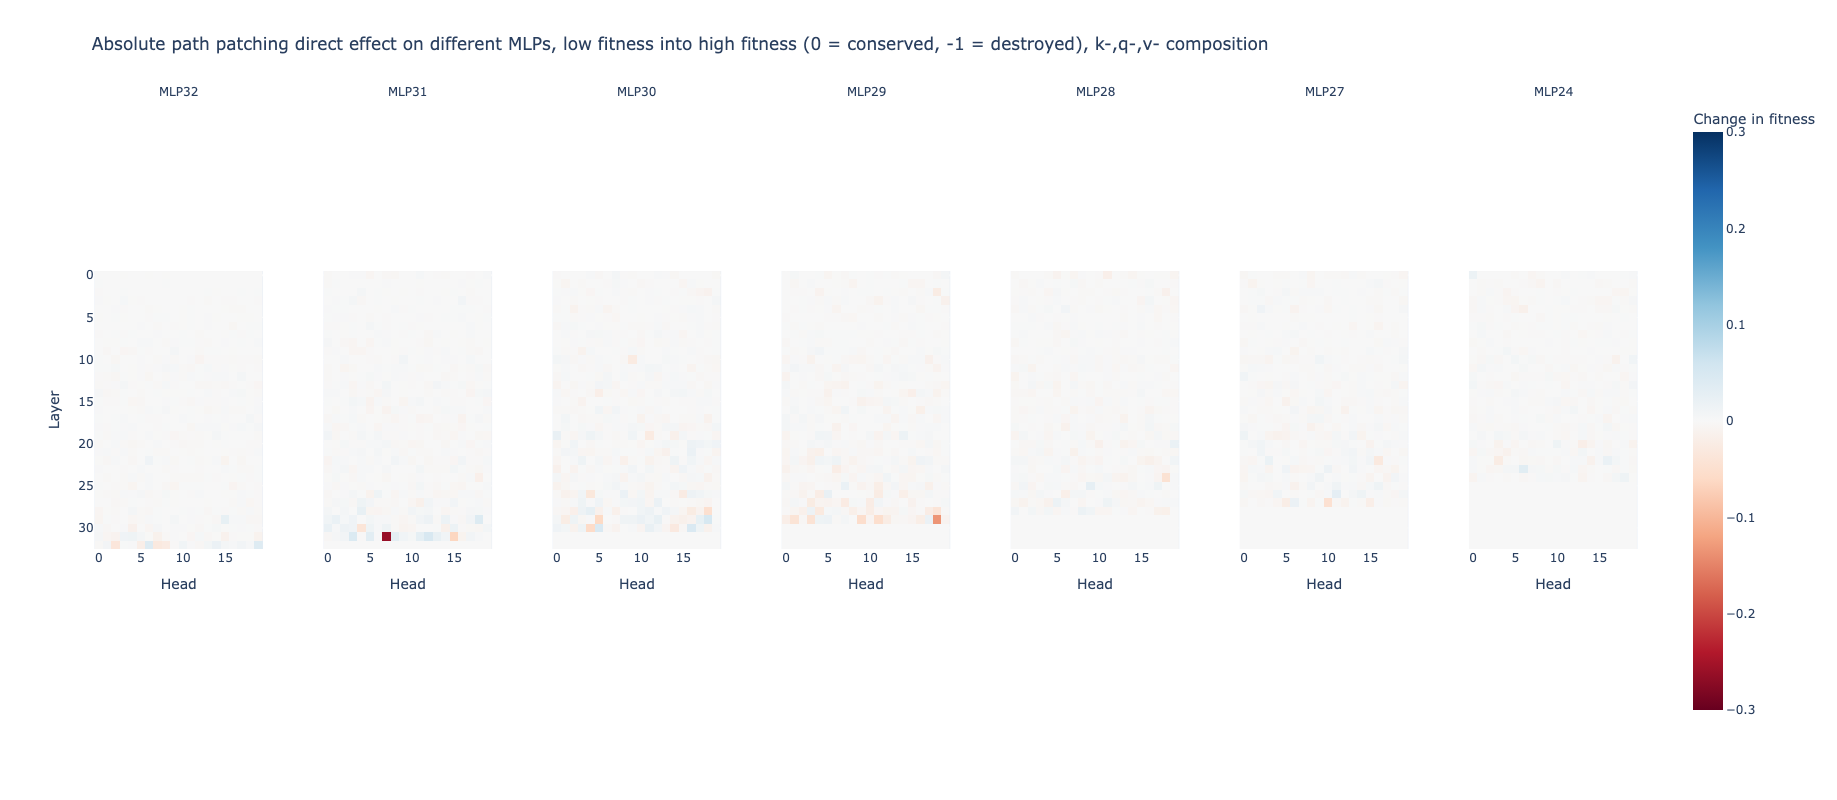

In [42]:
imshow(
    head_path_patch_all_mlp_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Absolute path patching direct effect on different MLPs, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=[f"MLP{mlp_idx}" for mlp_idx in [32, 31, 30, 29, 28, 27, 24]],
    width=1600,
    height=800,
    facet_col=0,
    range_color=(-0.3,0.3)
)

In [33]:
def abs_path_patch_mlp_input(
    orig_mlp_vector: Float[Tensor, "batch pos d_mlp"],
    hook: HookPoint,
    new_comp: Float[Tensor, "batch pos d_mlp"], # changed_mlp_vector
):
    orig_mlp_vector[...] = new_comp[...]
    return orig_mlp_vector


def abs_path_patch_mlp_to_mlp(
    model: HookedTransformer,
    receiver_mlps: list[int], # (layers)
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached attn. z
    orig_cache: ActivationCache, # cached attn. z
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers)
    
    layer_head_lns = [model.blocks[layer].ln2 for layer in receiver_mlps]
    resid_mid_names = [f"blocks.{layer}.hook_resid_mid" for layer in receiver_mlps]
    _, resid_mid_cache = model.run_with_cache(high_toks, names_filter = resid_mid_names)
    torch.cuda.empty_cache()

    W_mlp_in = model.W_in # [n_layer d_model d_mlp]
    b_mlp_in = model.b_in # # [n_layer d_mlp]
    
    with tqdm(total = (max(receiver_mlps)) * 1) as fancy_progress_bar:
        for layer in range(max(receiver_mlps)):

            mlp_layer_name = f"blocks.{layer}.hook_mlp_out"

            # STEP 2
            # new_resid_input= old_resid_input - old_head_output + new_head_output
            # new_head_output
            new_mlp_output = new_cache[mlp_layer_name]
            # old_head_output
            orig_mlp_output = orig_cache[mlp_layer_name]

            # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
            for r_ln, r_post_name, rl in zip(layer_head_lns, resid_mid_names, receiver_mlps):
                # only patch in things from strictly earlier layers
                if rl > layer:
                    receiver_mlp_name = f"blocks.{rl}.mlp.hook_pre"
                    new_resid_input = r_ln(resid_mid_cache[r_post_name] - orig_mlp_output + new_mlp_output)
                    new_comp = einops.einsum(new_resid_input, W_mlp_in[rl], "batch pos d_model, d_model d_mlp -> batch pos d_mlp") + b_mlp_in[rl] # [batch pos n_head d_head]
                    
                    model.add_hook(
                        receiver_mlp_name, 
                        functools.partial(abs_path_patch_mlp_input, new_comp=new_comp), 
                        dir="fwd"
                    )
                
            path_patched_logits = model(orig_dataset) # [batch pos d_model]
            # step 3, compute final logits
            path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
            torch.cuda.empty_cache()
    
            path_patch_results[layer] = patching_metric(path_patched_logits)
            
            fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results

In [34]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness
clean_toks = high_toks
corrupted_toks = low_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corrupted_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.05671152472496033


In [35]:
all_mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

In [36]:
# cache MLP outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corrupted_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()

In [41]:
mlp_abs_path_patch_all = []
for mlp in range(hooked_esm.cfg.n_layers):
    mlp_abs_path_patch_mlp = abs_path_patch_mlp_to_mlp(
        hooked_esm,
        receiver_mlps=[mlp],
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache
    )
    mlp_abs_path_patch_all.append(mlp_abs_path_patch_mlp)

0it [00:00, ?it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [01:19<00:00,  2.48s/it]


In [43]:
mlp_abs_path_patch_all_tensor = torch.stack(mlp_abs_path_patch_all, dim=0)

#### Fig 22.9 -- Absolute path patching (HIGH into LOW) from MLP to other MLP

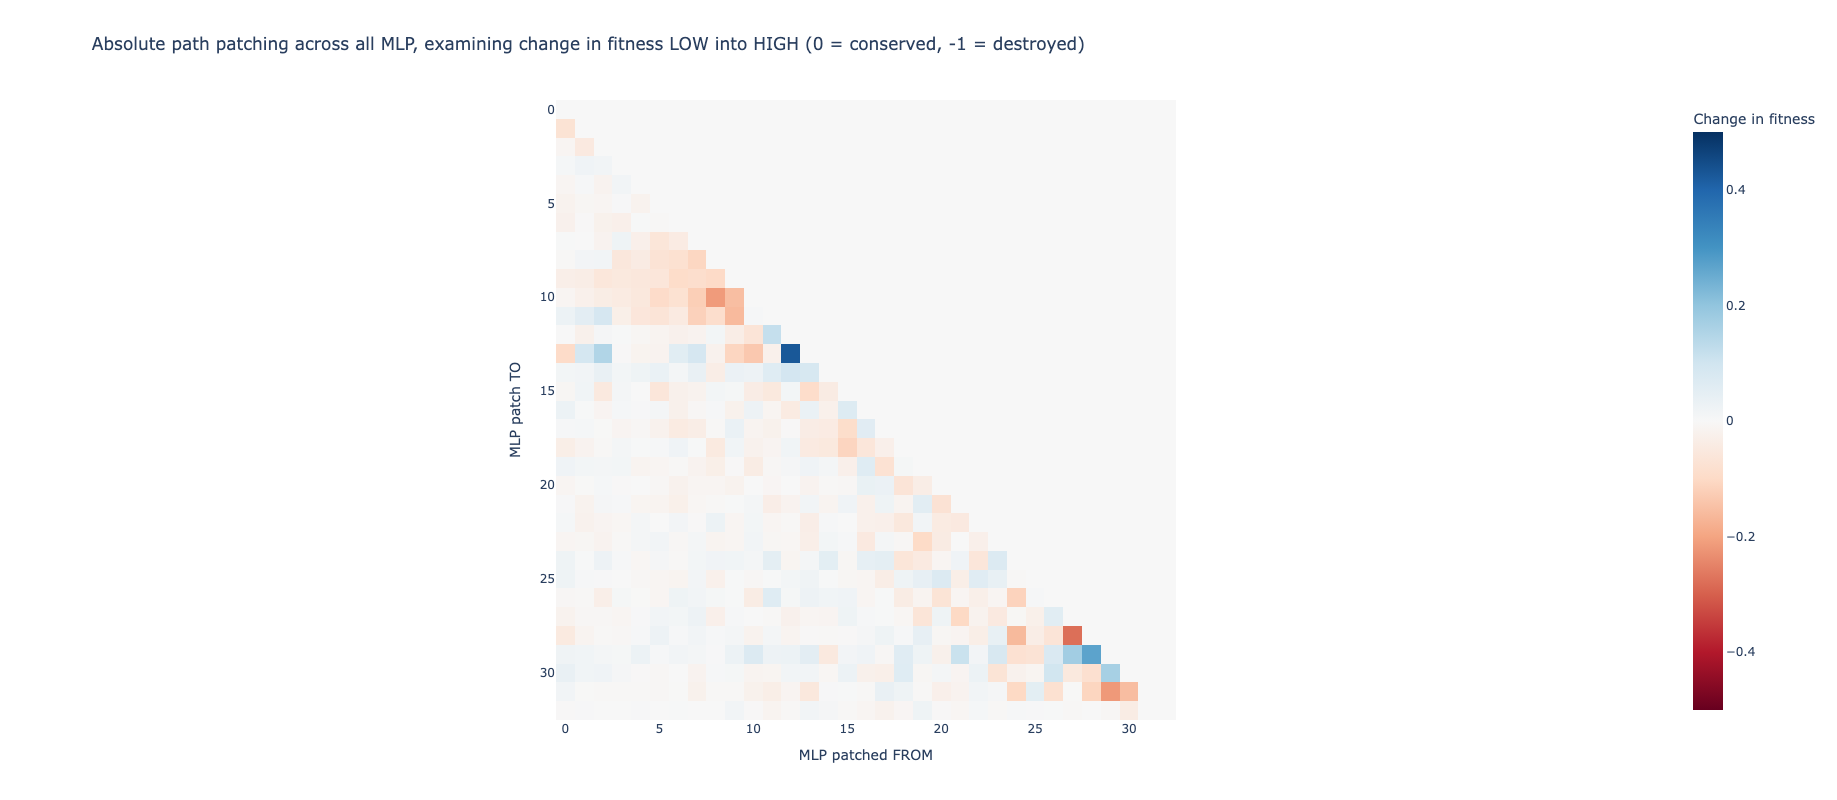

In [50]:
imshow(
    mlp_abs_path_patch_all_tensor,
    labels={"x": "MLP patched FROM", "y": "MLP patch TO", "color": "Change in fitness"},
    title="Absolute path patching across all MLP, examining change in fitness LOW into HIGH (0 = conserved, -1 = destroyed)",
    width=1400,
    height=800,
    range_color=(-0.5,0.5),
)